# 9. OPTIMIZATION RECOMMENDATIONS: Problematic Routes

### What Does This Cell Do?
Identifies routes that are underperforming or overcrowded and suggests actions.

### Logic
- **Overcrowded:** >90% Occupancy -> Increase Frequency
- **Underutilized:** <10% Occupancy -> Reduce Frequency / Use Minibus
- **Inefficient:** High capacity but low passenger count -> Review Route

### Output
- List of actionable recommendations

# EGO Data Analysis - Quick Version 
 
This notebook loads dated data from the **ego_data_clean.csv** file. 
 
- No PDF scraping 
- Runs fast 
- You can Run All

In [14]:
# load the CSV file with dates - CORRECTED VERSION WITH WEEKENDS
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# 1. LOAD DATA
csv_file = r"../data/ego_data_with_dates_CORRECTED.csv"

if not os.path.exists(csv_file):
    print("Lutfen once reparse_with_real_dates.py scriptini calistirin.")
else:
    df = pd.read_csv(csv_file)
    df["TARIH"] = pd.to_datetime(df["TARIH"])

    # 2. CREATE DERIVED COLUMNS (STOP COUNT & BÖLGE)
    # create STOP COUNT
    if "STOP COUNT" not in df.columns:
        df["STOP COUNT"] = df["GÜZERGAH"].apply(lambda x: len(str(x).split("-")) if pd.notna(x) else 0)
    
    # create BÖLGE (Region)
    if "BÖLGE" not in df.columns:
        df["BÖLGE"] = df["GÜZERGAH"].apply(lambda x: str(x).split("-")[0].strip() if pd.notna(x) else "Unknown")
        
    # 3. CREATE STOP COUNTS (Global variable needed for other cells)
    all_locations = []
    for route in df["GÜZERGAH"].dropna():
        parts = str(route).split("-")
        all_locations.extend([p.strip() for p in parts if len(p.strip()) > 2])
    stop_counts = Counter(all_locations)


    print(f"Data Loaded: {len(df):,} rows")
    print(f"Date Range: {df["TARIH"].min().date()} -> {df["TARIH"].max().date()}")
    print(f"Unique Routes: {df["HAT NO"].nunique()}")
    print(f"Columns: {list(df.columns)}")
    print(f"stop_counts initialized: {len(stop_counts)} unique stops")

    # Weekend check
    weekend_data = df[df["TARIH"].dt.dayofweek >= 5]
    weekday_data = df[df["TARIH"].dt.dayofweek < 5]
    print(f"Weekday Rows: {len(weekday_data):,}")
    print(f"Weekend Rows: {len(weekend_data):,}")

    print()
    display(df.head())

Data Loaded: 112,930 rows
Date Range: 2023-12-24 -> 2024-10-20
Unique Routes: 550
Columns: ['TARIH', 'HAT NO', 'GÜZERGAH', 'SEFER SAYISI', 'ARAÇ KAPASİTESİ', 'TAŞINAN YOLCU SAYISI', 'DOLULUK ORANI', 'STOP COUNT', 'BÖLGE']
stop_counts initialized: 691 unique stops
Weekday Rows: 87,734
Weekend Rows: 25,196



,TARIH,HAT NO,GÜZERGAH,SEFER SAYISI,ARAÇ KAPASİTESİ,TAŞINAN YOLCU SAYISI,DOLULUK ORANI,STOP COUNT,BÖLGE
0,2023-12-24,101,Gölbaşı-Haymana Yolu-Bahçelievler,6,980,138,14,3,Gölbaşı
1,2023-12-24,106-3,Gölbaşı-Yurtlar-Aşti-Akköprü-Ulus,55,7560,4873,64,5,Gölbaşı
2,2023-12-24,106-4,Ulus-Kızılay-Gölbaşı-Yurtlar,61,7910,4461,56,4,Ulus
3,2023-12-24,107-6,Gölbaşı-Toki-Aşti-Akköprü-Ulus,5,490,143,29,5,Gölbaşı
4,2023-12-24,108,Gölbaşı-Haymana Yolu-Hacılar Mah.,3,420,63,15,3,Gölbaşı


# Time Series Analysis 
 
In this section we will analyze by date: 
- Daily passenger trends 
- Weekday vs Weekend comparison 
- Monthly changes 
- Performance of specific routes over time 

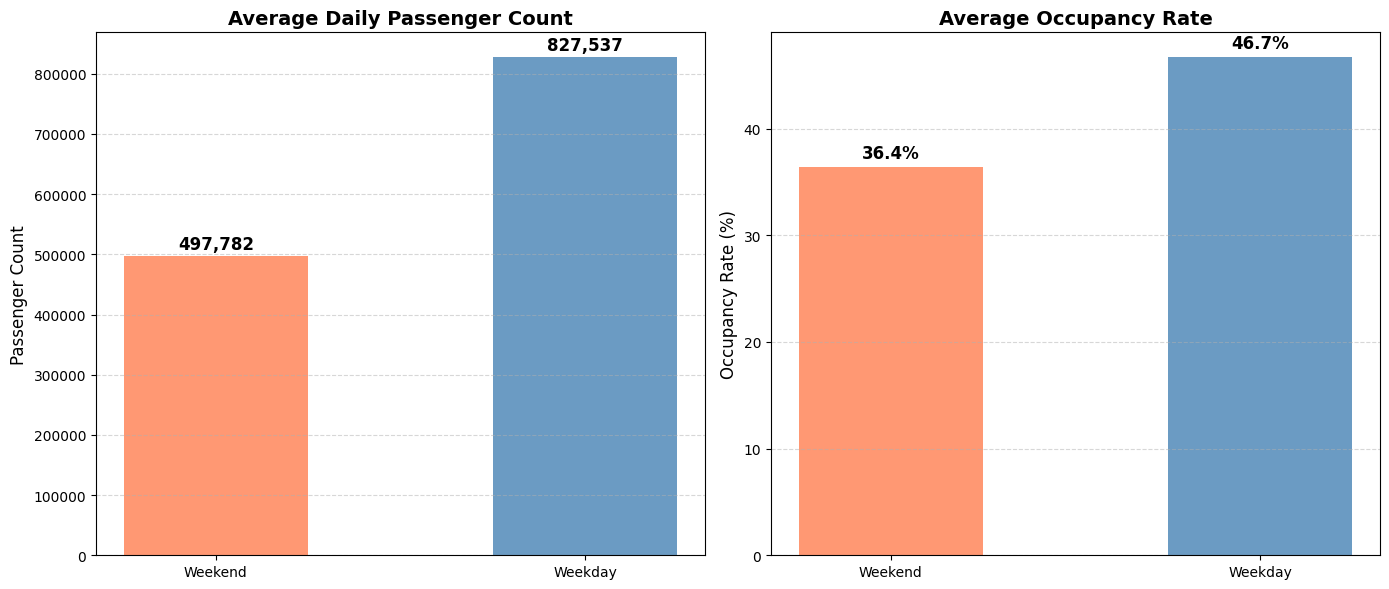

WEEKDAY vs WEEKEND COMPARISON
WEEKDAY Avg Passenger: 827,537
WEEKEND Avg Passenger: 497,782
Difference: Weekday has 66.2% more passengers than Weekend


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation (weekday vs weekend)
df_with_day = df.copy() 
df_with_day['Day Name'] = df_with_day['TARIH'].dt.day_name() 
df_with_day['Is Weekday'] = df_with_day['TARIH'].dt.dayofweek < 5 

# Group by date first to get daily totals
daily_grouped = df_with_day.groupby(['TARIH', 'Is Weekday']).agg({ 
    'TAŞINAN YOLCU SAYISI': 'sum', 
    'DOLULUK ORANI': 'mean' 
}).reset_index()

# Calculate averages for Weekday vs Weekend
avg_stats = daily_grouped.groupby('Is Weekday').mean(numeric_only=True).reset_index()
avg_stats['Labels'] = avg_stats['Is Weekday'].map({True: 'Weekday', False: 'Weekend'})

# Create Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Passenger Count Comparison
colors = ['steelblue' if x else 'coral' for x in avg_stats['Is Weekday']]
bars1 = axes[0].bar(avg_stats['Labels'], avg_stats['TAŞINAN YOLCU SAYISI'], 
                    color=colors, alpha=0.8, width=0.5)

for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 5000, f'{yval:,.0f}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Average Daily Passenger Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Passenger Count', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Occupancy Rate Comparison
bars2 = axes[1].bar(avg_stats['Labels'], avg_stats['DOLULUK ORANI'], 
                    color=colors, alpha=0.8, width=0.5)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_title('Average Occupancy Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print Summary
print("="*60)
print("WEEKDAY vs WEEKEND COMPARISON")
print("="*60)
wd = avg_stats[avg_stats['Is Weekday'] == True].iloc[0]
we = avg_stats[avg_stats['Is Weekday'] == False].iloc[0]

print(f"WEEKDAY Avg Passenger: {wd['TAŞINAN YOLCU SAYISI']:,.0f}")
print(f"WEEKEND Avg Passenger: {we['TAŞINAN YOLCU SAYISI']:,.0f}")
diff = ((wd['TAŞINAN YOLCU SAYISI'] - we['TAŞINAN YOLCU SAYISI']) / we['TAŞINAN YOLCU SAYISI']) * 100
print(f"Difference: Weekday has {diff:.1f}% more passengers than Weekend")

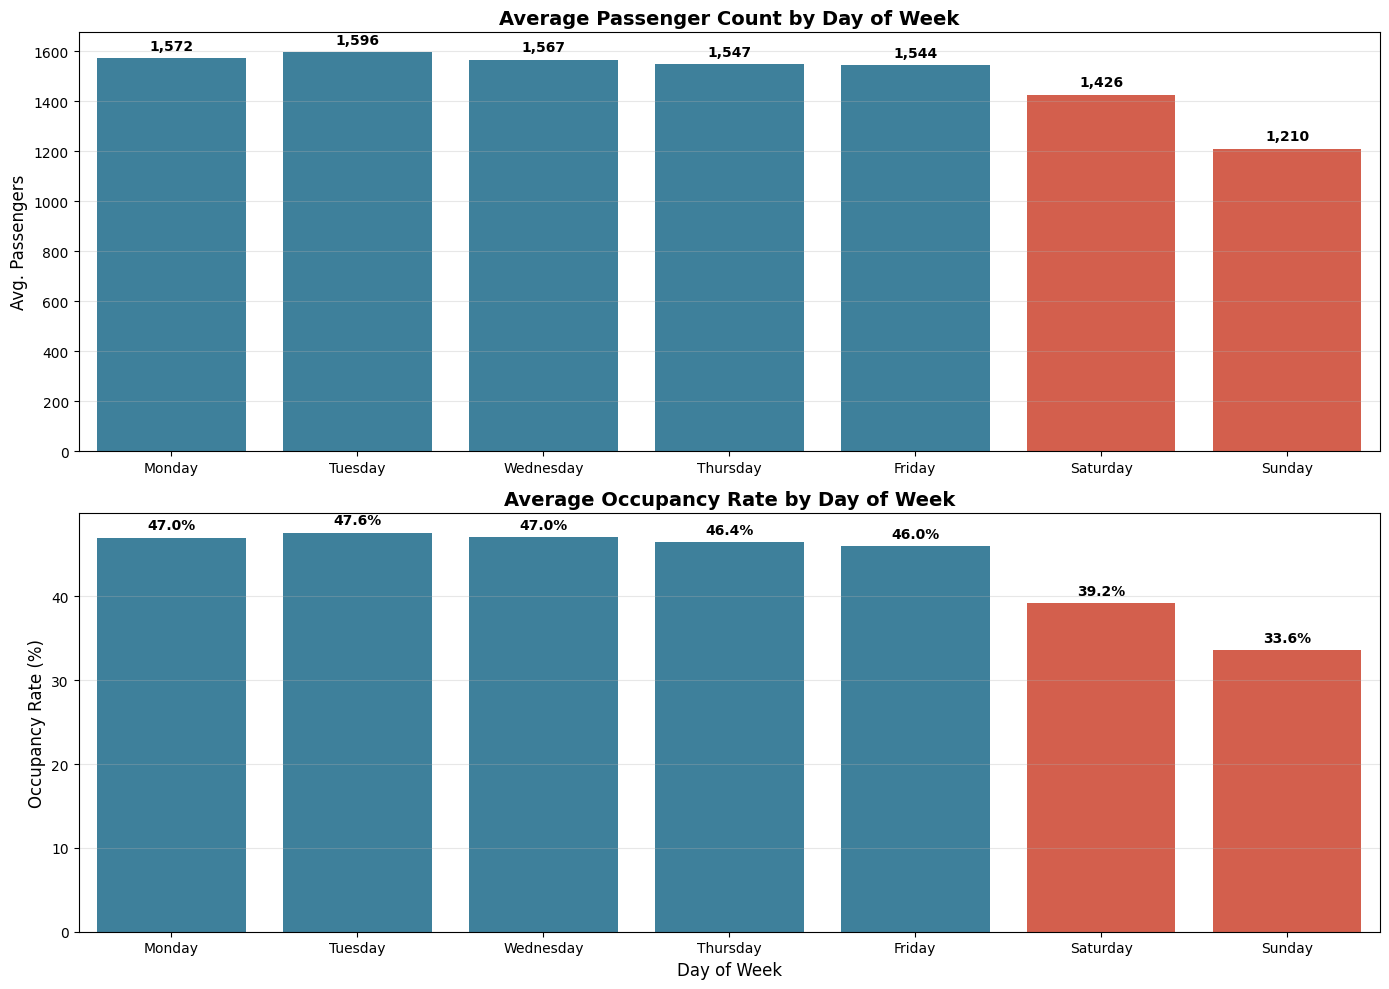

Legend: Blue = Weekday, Orange = Weekend


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Day of Week Analysis (Monday to Sunday)
df_day_analysis = df.copy()
df_day_analysis['Day_Name'] = df_day_analysis['TARIH'].dt.day_name()

# Day order (Monday to Sunday)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_day_analysis['Day_Name'] = pd.Categorical(df_day_analysis['Day_Name'], categories=days_order, ordered=True)

# Calculate daily averages
day_stats = df_day_analysis.groupby('Day_Name', observed=True).agg({
    'TAŞINAN YOLCU SAYISI': 'mean',
    'DOLULUK ORANI': 'mean'
}).reset_index()

# Color palette (Weekdays: Blue, Weekends: Orange)
colors = ['#2E86AB', '#2E86AB', '#2E86AB', '#2E86AB', '#2E86AB', '#E94F37', '#E94F37']

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Average Passengers by Day
sns.barplot(x='Day_Name', y='TAŞINAN YOLCU SAYISI', data=day_stats, ax=axes[0], palette=colors)

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f'{p.get_height():,.0f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 9), textcoords='offset points', fontweight='bold')

axes[0].set_title('Average Passenger Count by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Avg. Passengers', fontsize=12)
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.3)

# 2. Average Occupancy by Day
sns.barplot(x='Day_Name', y='DOLULUK ORANI', data=day_stats, ax=axes[1], palette=colors)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'{p.get_height():.1f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 9), textcoords='offset points', fontweight='bold')

axes[1].set_title('Average Occupancy Rate by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Legend: Blue = Weekday, Orange = Weekend")

TOP 5 MOST POPULAR ROUTES (Total Passengers):
1. Route 266: 3,305,382 passengers
2. Route 481: 2,308,113 passengers
3. Route 312: 2,061,051 passengers
4. Route 414: 2,002,217 passengers
5. Route 320: 1,974,838 passengers



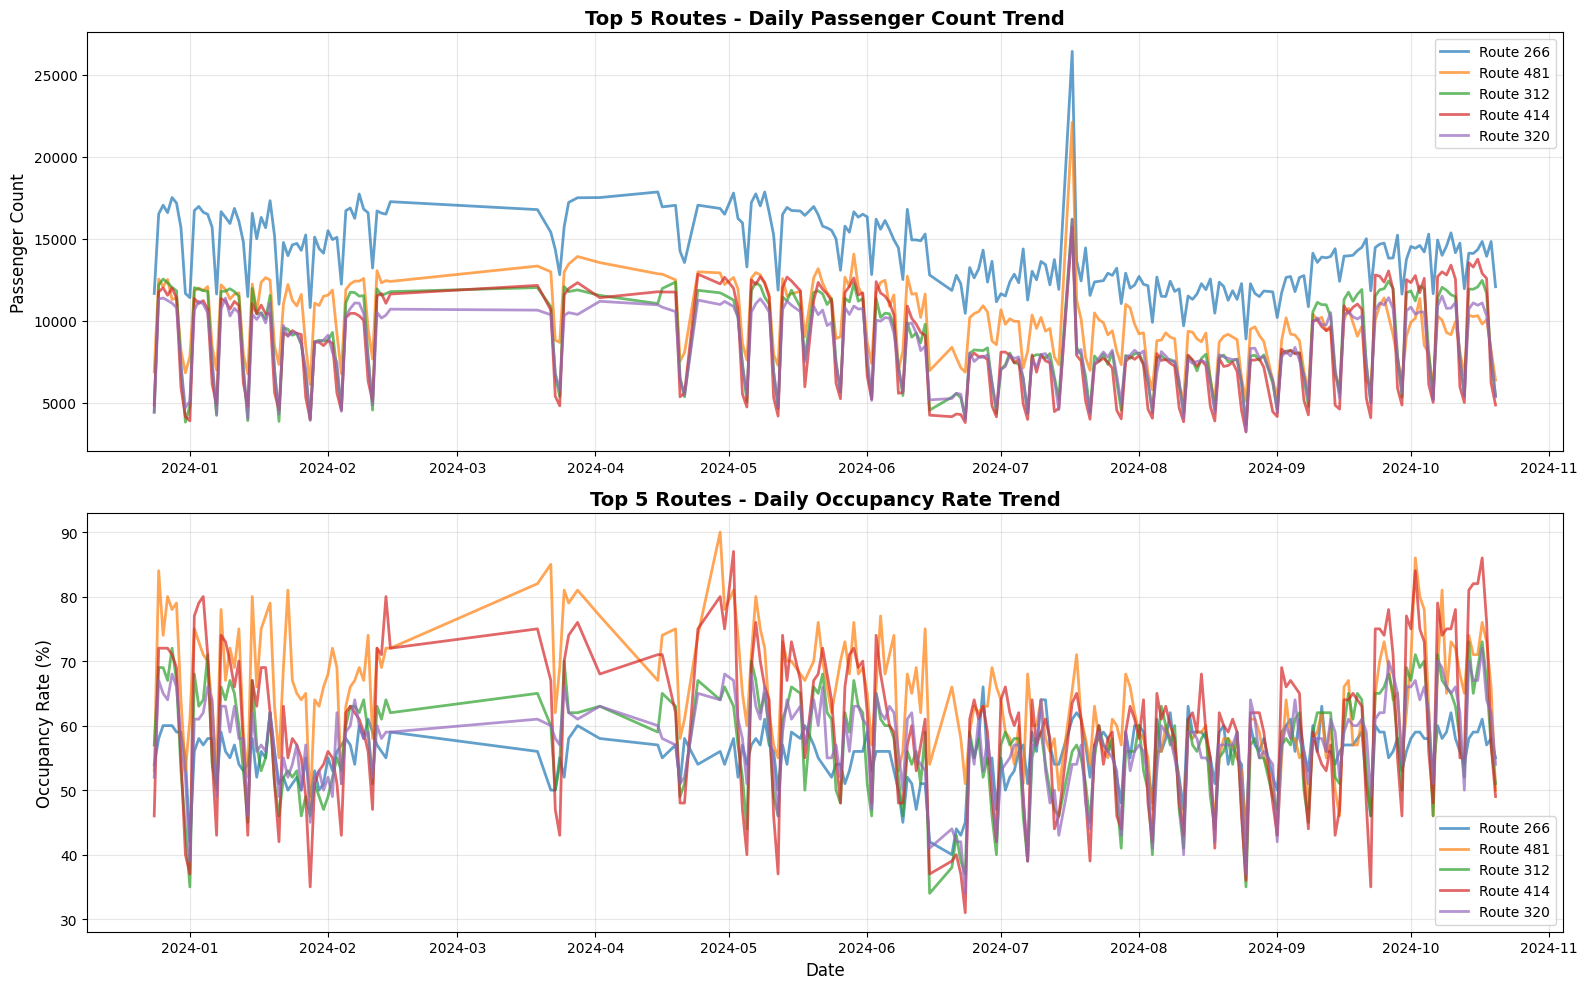


TOP 5 ROUTES STATISTICS

Route 266:
  Total Passengers: 3,305,382
  Average Daily: 14,186
  Average Occupancy: 55.6%
  Route Path: Bağlum-Ulus-15 Temmuz Kızılay Milli İrade Meydanı-...

Route 481:
  Total Passengers: 2,308,113
  Average Daily: 9,906
  Average Occupancy: 64.3%
  Route Path: Uyanış-Asfalt-15 Temmuz Kızılay Milli İrade Meydan...

Route 312:
  Total Passengers: 2,061,051
  Average Daily: 8,846
  Average Occupancy: 57.0%
  Route Path: Karapürçek-Beşikkaya-Sıhhiye-Ulus...

Route 414:
  Total Passengers: 2,002,217
  Average Daily: 8,593
  Average Occupancy: 60.2%
  Route Path: Aktepe-İvedik Metro İst....

Route 320:
  Total Passengers: 1,974,838
  Average Daily: 8,476
  Average Occupancy: 57.2%
  Route Path: Karapürçek-Ekin Mh-Başak Mahalesi-Sıhhiye-Gar-Ulus...


In [17]:
# Top 5 Most Popular Routes - Performance Over Time

# Most passengers transported (total)
top_routes = df.groupby('HAT NO')['TAŞINAN YOLCU SAYISI'].sum().nlargest(5)

print("TOP 5 MOST POPULAR ROUTES (Total Passengers):")
print("="*60)
for i, (route, total) in enumerate(top_routes.items(), 1):
    print(f"{i}. Route {route}: {total:,} passengers")
print()

# Daily performance of these routes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Daily Passenger Count
for route in top_routes.index[:5]:
    route_data = df[df['HAT NO'] == route].groupby('TARIH')['TAŞINAN YOLCU SAYISI'].sum()
    axes[0].plot(route_data.index, route_data.values, label=f'Route {route}',
                 linewidth=2, alpha=0.7)

axes[0].set_title('Top 5 Routes - Daily Passenger Count Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Passenger Count', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# 2. Daily Occupancy Rate
for route in top_routes.index[:5]:
    route_data = df[df['HAT NO'] == route].groupby('TARIH')['DOLULUK ORANI'].mean()
    axes[1].plot(route_data.index, route_data.values, label=f'Route {route}',
                 linewidth=2, alpha=0.7)

axes[1].set_title('Top 5 Routes - Daily Occupancy Rate Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Occupancy Rate (%)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\n" + "="*80)
print("TOP 5 ROUTES STATISTICS")
print("="*80)
for route in top_routes.index:
    route_df = df[df['HAT NO'] == route]
    print(f"\nRoute {route}:")
    print(f"  Total Passengers: {route_df['TAŞINAN YOLCU SAYISI'].sum():,}")
    print(f"  Average Daily: {route_df.groupby('TARIH')['TAŞINAN YOLCU SAYISI'].sum().mean():,.0f}")
    print(f"  Average Occupancy: {route_df['DOLULUK ORANI'].mean():.1f}%")
    print(f"  Route Path: {route_df['GÜZERGAH'].iloc[0][:50]}...")

--- 
## 4. Location Analysis: Route Path Parsing 
 
### What Does This Cell Do? 
Parses and analyzes location names in the route path column. 
 
### How It Works? 
1. Splits the route path column by dash (`-`) separator 
2. Calculates how many stops each route contains 
3. Counts the most frequently occurring stop/neighborhood names 
4. Creates a location frequency list 
 
### Example 
``` 
"Gölbaşı-Haymana Yolu-Bahçelievler-Ulus" 
↓ 
["Gölbaşı", "Haymana Yolu", "Bahçelievler", "Ulus"] 
stop count: 4 
``` 
 
### Output 
- Stop count for each route 
- Top 30 most frequent locations 
- Stop count distribution 

# 5. SERVICE COVERAGE ANALYSIS: Hub Stops

### What Does This Cell Do?
Identifies which stops are served by how many different routes. Detects **Hub** (central) stops.

### How It Works?
1. Counts how many different routes pass through each stop.
2. Finds the stops with the most connections (hubs).
3. Identifies less served stops.

### What is a Hub?
High connectivity points where many routes intersect. Example: Kızılay, Ulus, Aşti.

### Output
- Top 20 Hub Stops
- Service coverage map
- Single-route stops (potential risk regions)

Stop data loaded: 50,912 rows
Columns: ['hat_adi', 'sira', 'durak_kodu', 'durak_adi', 'adres']

Total Stops: 5828
Hub Count (10+ routes): 857

Top 10 Hubs:


,Stop,Route Count
4172,SIHHİYE,193
3685,OPERA,188
3014,KIZILAY,183
2403,GÜVENPARK,99
999,ATATÜRK KÜLTÜR MERKEZİ,91
4959,YIBA ÇARŞISI,85
992,ATATÜRK ANADOLU LİSESİ,82
666,AKKÖPRÜ,75
4654,ULUS 100.YIL ÇARŞISI,74
868,ANKARA BÜYÜKŞEHİR BELEDİYESİ,73


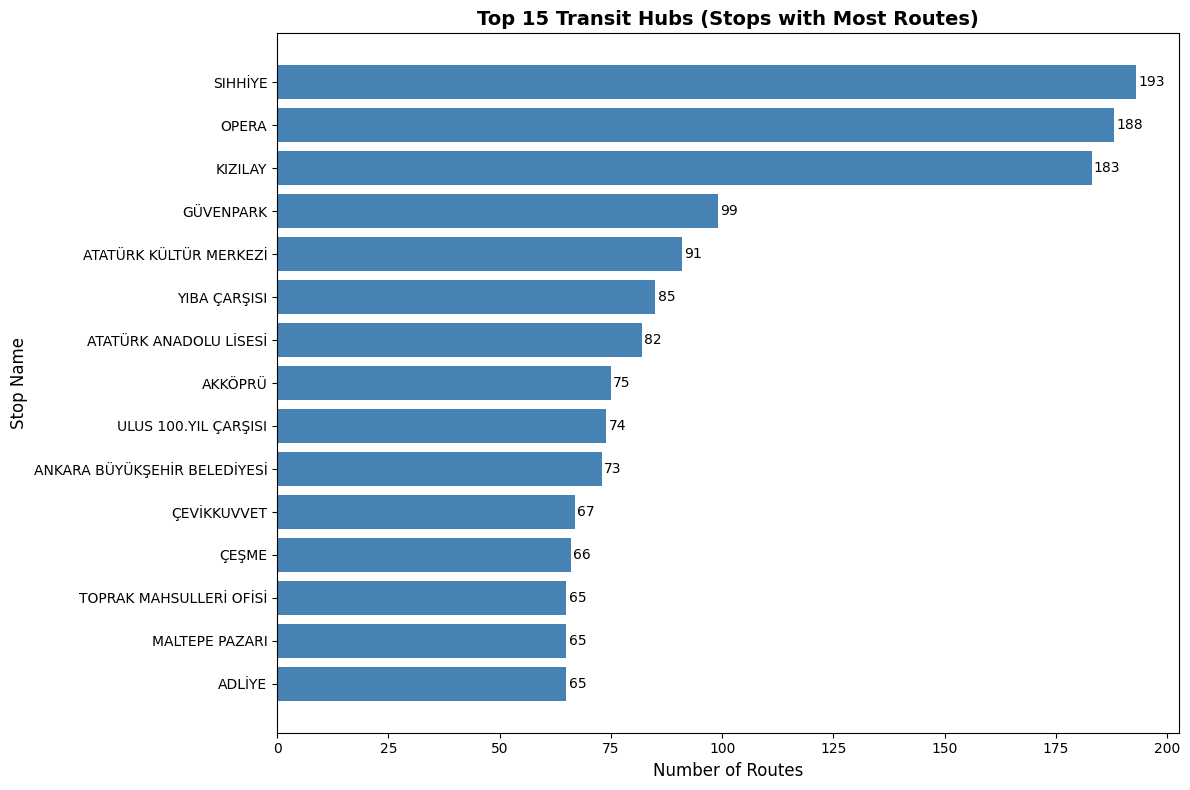

In [18]:
# Hub Analysis - Stops with Multiple Routes
import pandas as pd

# Load stop data
stops_file = "../data/ego_route_stops.csv"
stops_df = pd.read_csv(stops_file)

print(f"Stop data loaded: {len(stops_df):,} rows")
print(f"Columns: {list(stops_df.columns)}")

# Count how many routes serve each stop
stop_counts = stops_df.groupby('durak_adi')['hat_adi'].nunique()

stop_service_count = pd.DataFrame([
    {'Stop': stop, 'Route Count': count}
    for stop, count in stop_counts.items()
]).sort_values('Route Count', ascending=False)

# Detect Hubs (10+ routes)
hubs = stop_service_count[stop_service_count['Route Count'] >= 10]

print(f"\nTotal Stops: {len(stop_service_count)}")
print(f"Hub Count (10+ routes): {len(hubs)}")
print("\nTop 10 Hubs:")
display(hubs.head(10))

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
top_hubs = hubs.head(15)
bars = ax.barh(top_hubs['Stop'], top_hubs['Route Count'], color='steelblue')
ax.set_xlabel('Number of Routes', fontsize=12)
ax.set_ylabel('Stop Name', fontsize=12)
ax.set_title('Top 15 Transit Hubs (Stops with Most Routes)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 6. REGIONAL ANALYSIS: Performance by Main Regions

### What Does This Cell Do?
Groups routes by main regions and compares regional performance.

### How It Works?
1. Categorizes routes into regions based on the first word of the route path.
2. Calculates average metrics for each region:
   - Occupancy rate
   - Passenger count
   - Trip count
   - Vehicle capacity
3. Ranks regions by performance.

### Main Regions
- Gölbaşı, Batıkent, Sincan, Keçiören, Çankaya, Mamak, etc.

### Output
- Region-based statistics
- Comparative bar charts

REGIONAL STATISTICS (Top 20)


,Record Count,Avg Occupancy (%),Avg Passengers,Avg Trips,Avg Capacity
BÖLGE,,,,,
Gölbaşı,5878,35.80,426.17,7.24,998.87
Sincan,4990,45.68,1361.77,13.09,2313.54
Ulus,4317,53.35,1766.11,27.61,3012.08
Koru Metro İst.,3610,38.29,1332.86,20.29,2922.50
Hastane Metro,3280,48.21,1112.38,17.11,2333.17
Batıkent Metro,2972,56.18,1299.33,29.34,2071.95
Yenikent,2302,46.30,2469.52,19.42,4877.83
Aybü,2209,27.37,1675.16,18.51,3605.88
Koru Metro İstasyonu,2208,36.31,880.72,14.68,2144.91


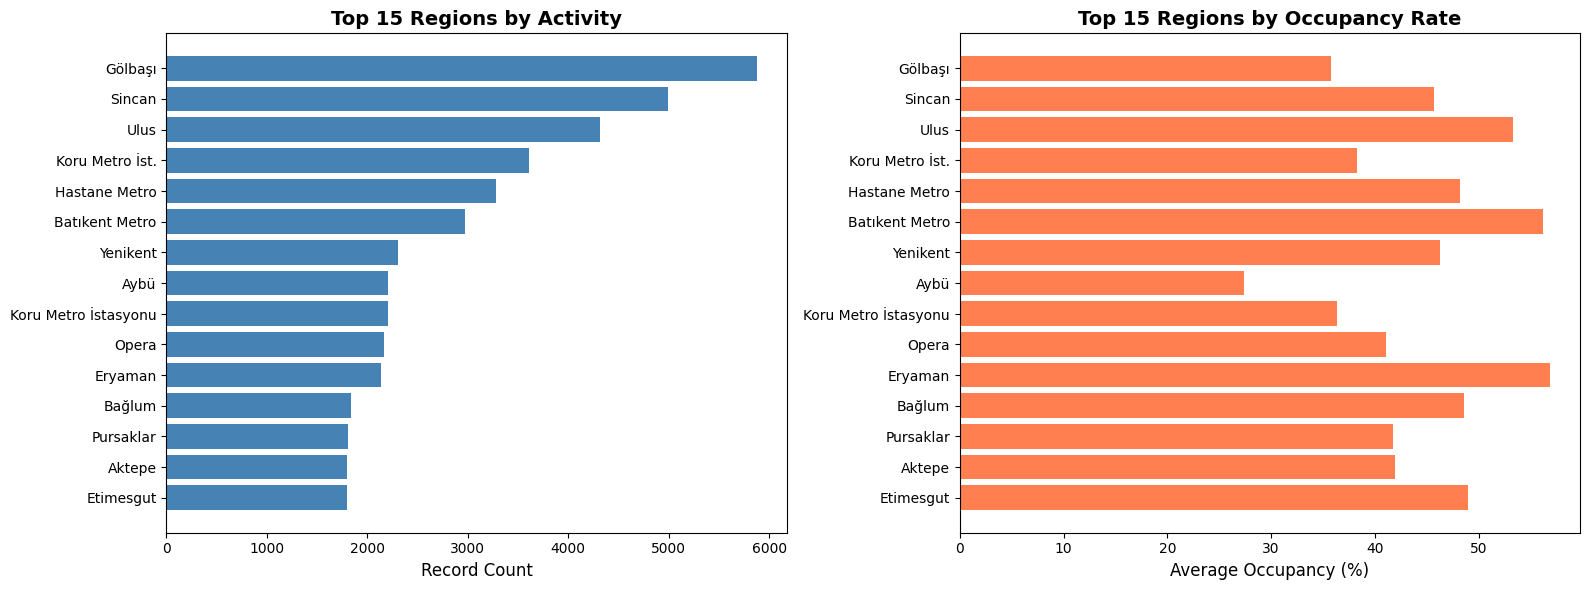

In [19]:
# Regional Analysis - Performance by Area

import re

# Extract region from route path
def extract_region(route_path):
    if pd.isna(route_path):
        return 'Unknown'
    parts = str(route_path).split('-')
    if len(parts) > 0:
        return parts[0].strip()
    return 'Unknown'

df['BÖLGE'] = df['GÜZERGAH'].apply(extract_region)

# Region based statistics (only available columns)
regional_stats = df.groupby('BÖLGE').agg({
    'HAT NO': 'count',
    'DOLULUK ORANI': 'mean',
    'TAŞINAN YOLCU SAYISI': 'mean',
    'SEFER SAYISI': 'mean',
    'ARAÇ KAPASİTESİ': 'mean'
}).round(2)

regional_stats.columns = ['Record Count', 'Avg Occupancy (%)', 'Avg Passengers', 
                          'Avg Trips', 'Avg Capacity']
regional_stats = regional_stats.sort_values('Record Count', ascending=False)

print("REGIONAL STATISTICS (Top 20)")
print("="*80)
display(regional_stats.head(20))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_regions = regional_stats.head(15)

# 1. Record Count by Region
axes[0].barh(top_regions.index, top_regions['Record Count'], color='steelblue')
axes[0].set_xlabel('Record Count', fontsize=12)
axes[0].set_title('Top 15 Regions by Activity', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 2. Average Occupancy by Region
axes[1].barh(top_regions.index, top_regions['Avg Occupancy (%)'], color='coral')
axes[1].set_xlabel('Average Occupancy (%)', fontsize=12)
axes[1].set_title('Top 15 Regions by Occupancy Rate', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 7. DIRECTIONAL ANALYSIS: Bidirectional Routes

### What Does This Cell Do?
Matches inbound and outbound routes (e.g. 104-1 vs 104-2) to check for symmetry.

### How It Works?
1. Detects route codes like `XXX-1` and `XXX-2`.
2. Compares passenger counts and occupancy rates between directions.
3. Detects unbalanced routes.

### Output
- Table of asymmetric routes
- Directional imbalance metrics

MOST IMBALANCED BIDIRECTIONAL ROUTES (Top 15 by Occupancy Difference)
Main Route Route 1  Occupancy 1 Route 2  Occupancy 2  Occupancy Diff
       560     560         80.0   560-1         19.2            60.8
       163   163-1         19.3   163-2         75.2            55.9
       540     540         61.6   540-6          5.8            55.8
       454     454         62.5   454-6         10.2            52.3
       114     114         26.8   114-1         75.7            48.9
       415     415         59.5   415-6         11.8            47.7
       721     721         33.9   721-1         81.2            47.3
       481     481         64.3   481-6         19.3            45.0
       530     530         61.7   530-2         16.9            44.9
       269     269         37.2   269-2         81.3            44.1
       504     504         57.7   504-6         13.6            44.1
       284     284         57.8   284-6         16.5            41.4
       555   555-2         55.3  

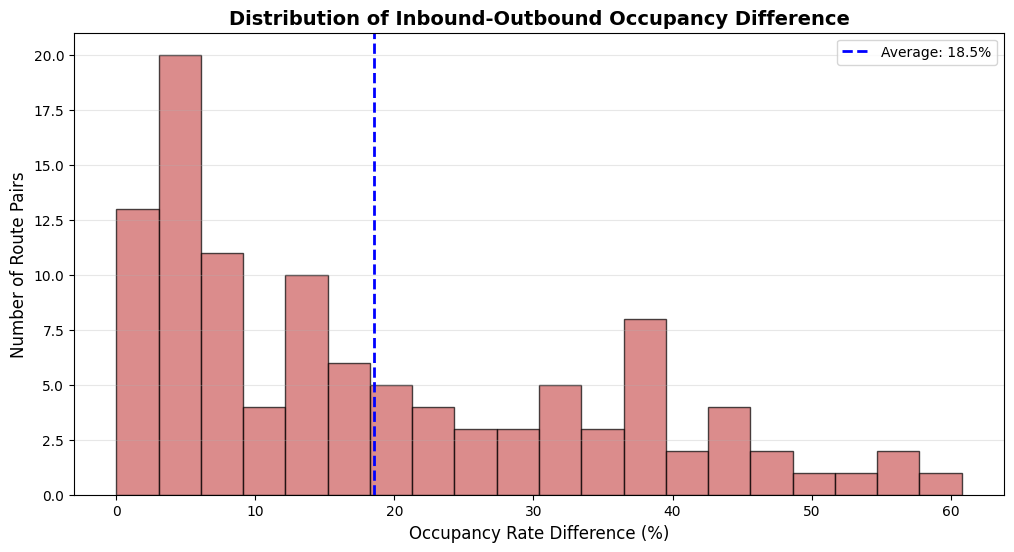

In [20]:
# Directional Analysis - Inbound vs Outbound Routes

# First, aggregate data by route (average per route)
route_summary = df.groupby('HAT NO').agg({
    'GÜZERGAH': 'first',
    'DOLULUK ORANI': 'mean',
    'TAŞINAN YOLCU SAYISI': 'sum',
    'SEFER SAYISI': 'sum'
}).reset_index()

# Extract main route code
route_summary['MAIN ROUTE'] = route_summary['HAT NO'].str.extract(r'(\d+)')[0]

# Find bidirectional routes (routes with same main code but different suffix like 101-1, 101-2)
direction_analysis = []

for main_route in route_summary['MAIN ROUTE'].unique():
    group = route_summary[route_summary['MAIN ROUTE'] == main_route]
    
    if len(group) >= 2:
        route1 = group.iloc[0]
        route2 = group.iloc[1]
        
        occupancy_diff = abs(route1['DOLULUK ORANI'] - route2['DOLULUK ORANI'])
        passenger_diff = abs(route1['TAŞINAN YOLCU SAYISI'] - route2['TAŞINAN YOLCU SAYISI'])
        
        direction_analysis.append({
            'Main Route': main_route,
            'Route 1': route1['HAT NO'],
            'Path 1': str(route1['GÜZERGAH'])[:40] + '...' if pd.notna(route1['GÜZERGAH']) else 'N/A',
            'Occupancy 1': round(route1['DOLULUK ORANI'], 1),
            'Route 2': route2['HAT NO'],
            'Path 2': str(route2['GÜZERGAH'])[:40] + '...' if pd.notna(route2['GÜZERGAH']) else 'N/A',
            'Occupancy 2': round(route2['DOLULUK ORANI'], 1),
            'Occupancy Diff': round(occupancy_diff, 1),
            'Passenger Diff': int(passenger_diff)
        })

if direction_analysis:
    direction_df = pd.DataFrame(direction_analysis).sort_values('Occupancy Diff', ascending=False)
    
    print("="*100)
    print("MOST IMBALANCED BIDIRECTIONAL ROUTES (Top 15 by Occupancy Difference)")
    print("="*100)
    print(direction_df.head(15)[['Main Route', 'Route 1', 'Occupancy 1', 'Route 2', 
                                  'Occupancy 2', 'Occupancy Diff']].to_string(index=False))
    
    print(f"\n{'='*100}")
    print("DIRECTIONAL IMBALANCE STATISTICS")
    print("="*100)
    print(f"Total Bidirectional Route Pairs: {len(direction_df)}")
    print(f"Average Occupancy Difference: {direction_df['Occupancy Diff'].mean():.2f}%")
    print(f"Maximum Occupancy Difference: {direction_df['Occupancy Diff'].max():.0f}%")
    
    # Visualization
    plt.figure(figsize=(12, 6))
    plt.hist(direction_df['Occupancy Diff'], bins=20, edgecolor='black',
             color='indianred', alpha=0.7)
    plt.xlabel('Occupancy Rate Difference (%)', fontsize=12)
    plt.ylabel('Number of Route Pairs', fontsize=12)
    plt.title('Distribution of Inbound-Outbound Occupancy Difference', fontsize=14, fontweight='bold')
    plt.axvline(direction_df['Occupancy Diff'].mean(), color='blue',
                linestyle='--', linewidth=2, label=f"Average: {direction_df['Occupancy Diff'].mean():.1f}%")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("No bidirectional route pairs found in the data.")

# 8. EFFICIENCY ANALYSIS: Stop Count vs Performance

### What Does This Cell Do?
Analyzes the relationship between route length (number of stops) and performance metrics.

### How It Works?
1. Correlates the number of stops with passenger count and occupancy.
2. Identifies if longer routes are more efficient or less efficient.

### Output
- Correlation analysis
- Efficiency scatter plot

ROUTE LENGTH CATEGORY ANALYSIS


,Avg Occupancy (%),Avg Passengers,Avg Trips,Unique Routes
ROUTE CATEGORY,,,,
Short (1-3),44.03,1207.40,16.82,351
Medium (4-6),45.39,2083.73,21.44,194
Long (7+),43.85,760.66,9.17,10


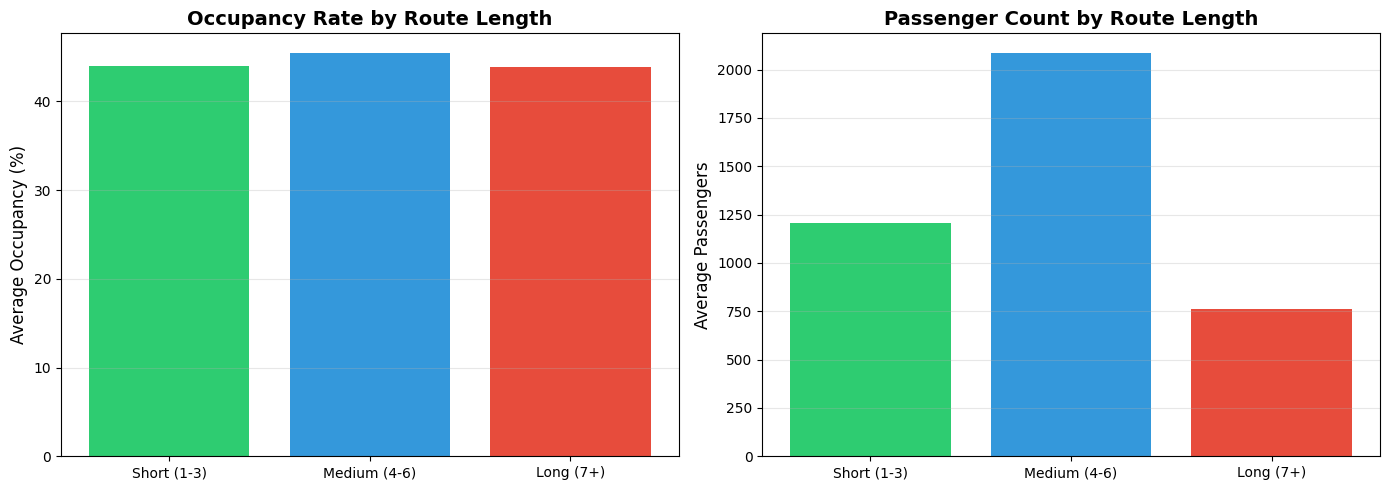

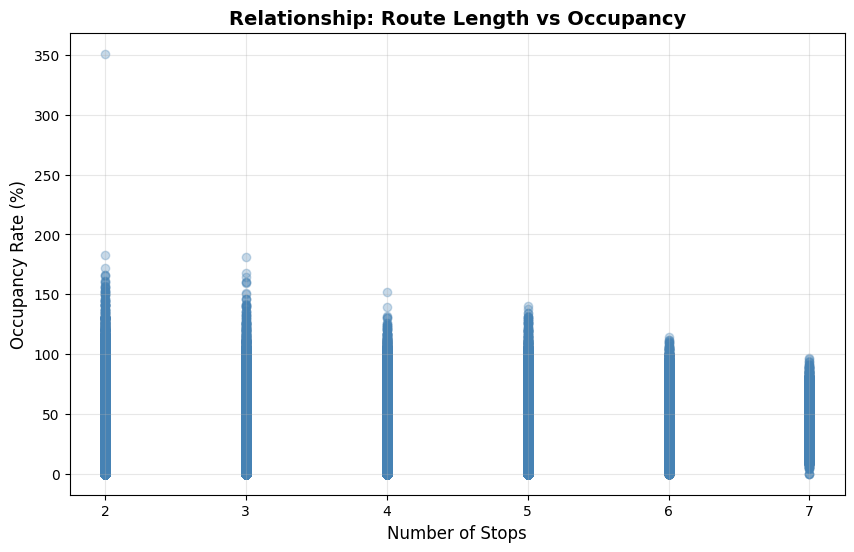

In [21]:
# Efficiency Analysis - Route Length vs Performance

# Calculate stop count from route path (count dashes + 1)
def count_stops(route_path):
    if pd.isna(route_path):
        return 0
    return len(str(route_path).split('-'))

df['STOP COUNT'] = df['GÜZERGAH'].apply(count_stops)

# Categorize route length
def categorize_route_length(stop_count):
    if stop_count <= 3:
        return 'Short (1-3)'
    elif stop_count <= 6:
        return 'Medium (4-6)'
    else:
        return 'Long (7+)'

df['ROUTE CATEGORY'] = df['STOP COUNT'].apply(categorize_route_length)

# Category based statistics
category_stats = df.groupby('ROUTE CATEGORY').agg({
    'DOLULUK ORANI': 'mean',
    'TAŞINAN YOLCU SAYISI': 'mean',
    'SEFER SAYISI': 'mean',
    'HAT NO': 'nunique'
}).round(2)

category_stats.columns = ['Avg Occupancy (%)', 'Avg Passengers', 'Avg Trips', 'Unique Routes']
category_stats = category_stats.reindex(['Short (1-3)', 'Medium (4-6)', 'Long (7+)'])

print("ROUTE LENGTH CATEGORY ANALYSIS")
print("="*60)
display(category_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Occupancy by Category
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].bar(category_stats.index, category_stats['Avg Occupancy (%)'], color=colors)
axes[0].set_ylabel('Average Occupancy (%)', fontsize=12)
axes[0].set_title('Occupancy Rate by Route Length', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 2. Passengers by Category
axes[1].bar(category_stats.index, category_stats['Avg Passengers'], color=colors)
axes[1].set_ylabel('Average Passengers', fontsize=12)
axes[1].set_title('Passenger Count by Route Length', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot: Stop Count vs Occupancy
plt.figure(figsize=(10, 6))
plt.scatter(df['STOP COUNT'], df['DOLULUK ORANI'], alpha=0.3, color='steelblue')
plt.xlabel('Number of Stops', fontsize=12)
plt.ylabel('Occupancy Rate (%)', fontsize=12)
plt.title('Relationship: Route Length vs Occupancy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# 9. OPTIMIZATION RECOMMENDATIONS: Problematic Routes

### What Does This Cell Do?
Identifies routes that are underperforming or overcrowded and suggests actions.

### Logic
- **Overcrowded:** >90% Occupancy -> Increase Frequency
- **Underutilized:** <10% Occupancy -> Reduce Frequency / Use Minibus
- **Inefficient:** High capacity but low passenger count -> Review Route

### Output
- List of actionable recommendations

In [22]:
# Optimization Recommendations - Problem Routes Detection

# 1. Cancellation Candidates (Low occupancy + Few passengers)
cancellation_candidates = df[
    (df['DOLULUK ORANI'] < 30) &
    (df['TAŞINAN YOLCU SAYISI'] < 100)
].sort_values('TAŞINAN YOLCU SAYISI')

# 2. Capacity Increase Candidates (High occupancy)
capacity_increase_candidates = df[
    df['DOLULUK ORANI'] > 85
].sort_values('DOLULUK ORANI', ascending=False)

# 3. Route Optimization Candidates (Long route + Low occupancy)
# First ensure STOP COUNT exists
if 'STOP COUNT' not in df.columns:
    df['STOP COUNT'] = df['GÜZERGAH'].apply(lambda x: len(str(x).split('-')) if pd.notna(x) else 0)

route_optimization_candidates = df[
    (df['STOP COUNT'] >= 7) &
    (df['DOLULUK ORANI'] < 40)
].sort_values('DOLULUK ORANI')

print("="*100)
print("1. CANCELLATION CANDIDATES (Low Occupancy + Few Passengers)")
print("="*100)
print(f"Total {len(cancellation_candidates)} routes identified.\n")
if len(cancellation_candidates) > 0:
    print(cancellation_candidates[['HAT NO', 'GÜZERGAH', 'DOLULUK ORANI',
                                   'TAŞINAN YOLCU SAYISI', 'SEFER SAYISI']].head(10).to_string(index=False))
else:
    print("No cancellation candidates found.")

print(f"\n{'='*100}")
print("2. CAPACITY INCREASE CANDIDATES (Occupancy >85%)")
print("="*100)
print(f"Total {len(capacity_increase_candidates)} routes identified.\n")
if len(capacity_increase_candidates) > 0:
    print(capacity_increase_candidates[['HAT NO', 'GÜZERGAH', 'DOLULUK ORANI',
                                        'TAŞINAN YOLCU SAYISI', 'SEFER SAYISI',
                                        'ARAÇ KAPASİTESİ']].head(15).to_string(index=False))
else:
    print("No capacity increase candidates found.")

print(f"\n{'='*100}")
print("3. ROUTE OPTIMIZATION CANDIDATES (Long Route + Low Occupancy)")
print("="*100)
print(f"Total {len(route_optimization_candidates)} routes identified.\n")
if len(route_optimization_candidates) > 0:
    print(route_optimization_candidates[['HAT NO', 'GÜZERGAH', 'STOP COUNT',
                                         'DOLULUK ORANI', 'TAŞINAN YOLCU SAYISI']].head(10).to_string(index=False))
else:
    print("No route optimization candidates found.")

# Summary
print(f"\n{'='*100}")
print("OPTIMIZATION RECOMMENDATIONS SUMMARY")
print("="*100)
print(f"✗ Cancellation Candidates: {len(cancellation_candidates)} routes")
print(f"↑ Capacity Increase: {len(capacity_increase_candidates)} routes")
print(f"🔄 Route Optimization: {len(route_optimization_candidates)} routes")
total_optimization = len(cancellation_candidates) + len(capacity_increase_candidates) + len(route_optimization_candidates)
print(f"\nTotal Optimization Potential: {total_optimization} routes")
print(f"Percentage of All Records: {(total_optimization / len(df) * 100):.1f}%")

1. CANCELLATION CANDIDATES (Low Occupancy + Few Passengers)
Total 16561 routes identified.

HAT NO                                                                                              GÜZERGAH  DOLULUK ORANI  TAŞINAN YOLCU SAYISI  SEFER SAYISI
   491                                                                 Aybü-Esenboğa-Melihşah-Yazır-Kutuören              0                     0             0
 502-2                                                                   Kahramankazan-Eryaman 1-2 İstasyonu              0                     0             0
   466    Çubuk-Tahtayazı-Dağkalfat-Kösrelik-Demirci (Perşembe, Cuma ve Pazar Günleri Servis Verilmektedir.)              0                     0             2
   467 Çubuk-Kışlacık-Yeşilkent-Karagöl Mesire Alanı (Perşembe, Cuma ve Pazar Günleri Servis Verilmektedir.)              0                     0             2
   489                                                                  Kalaba Mah.-Cücük Mah.-Taşpınar Mah.

# 10. VISUALIZATION: Word Cloud (Location Cloud)

### What Does This Cell Do?
Visualizes the most frequently occurring location names in route paths.

### How It Works?
1. Extracts neighborhood and district names from route descriptions.
2. Creates a Word Cloud where larger words appear more frequently.

### Output
- Word Cloud Image

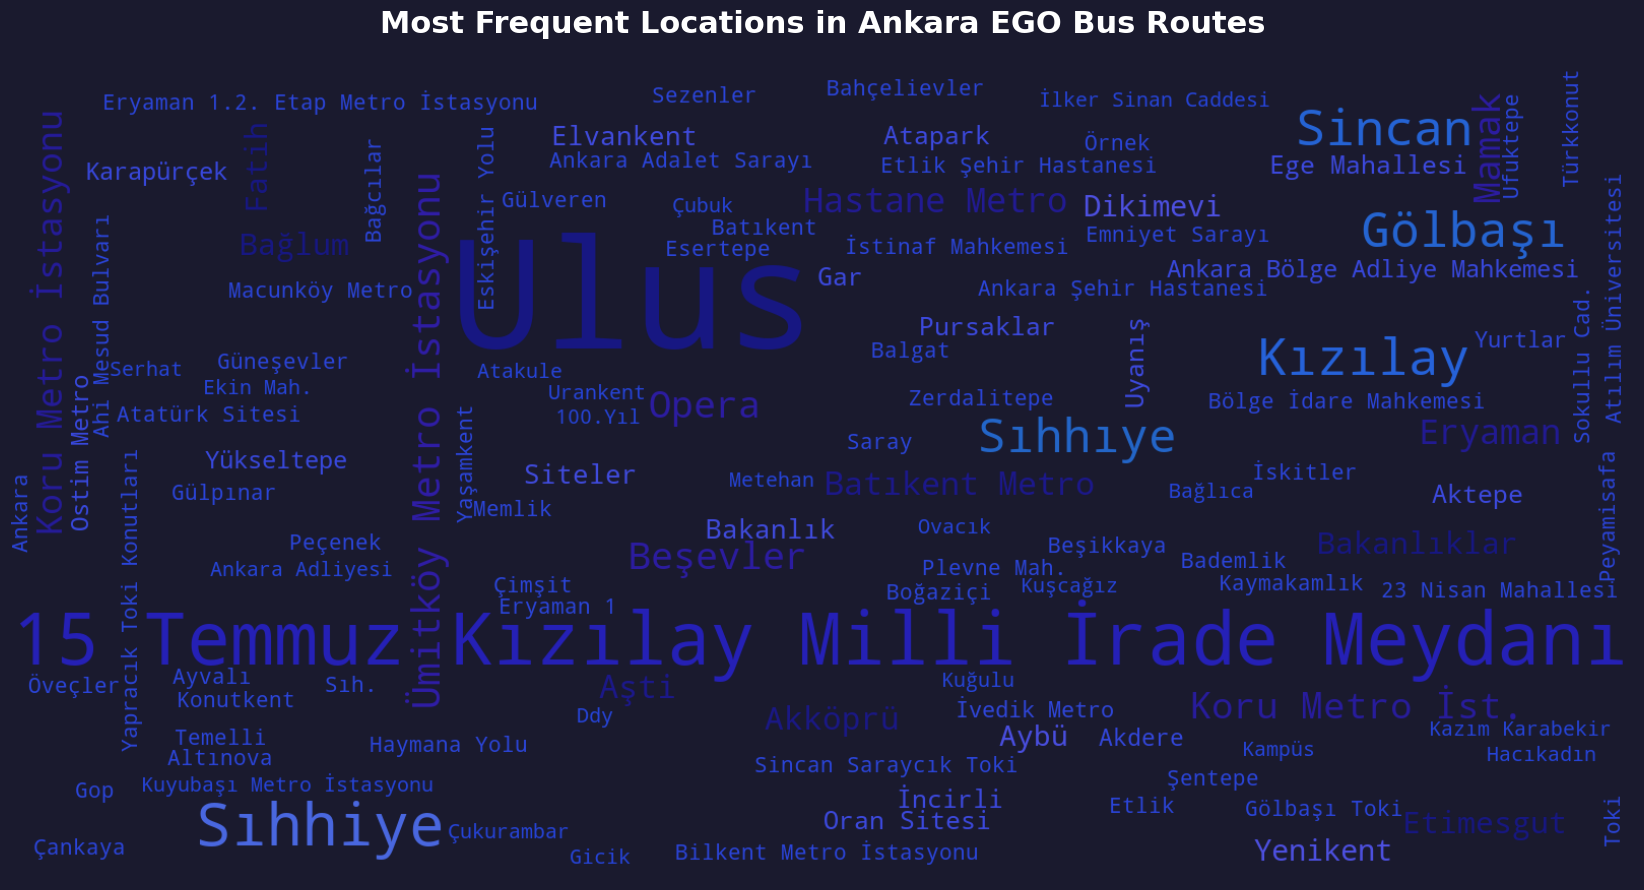

LOCATION FREQUENCY ANALYSIS
1. Ulus: 29051 routes
2. 15 Temmuz Kızılay Milli İrade Meydanı: 17252 routes
3. Sıhhiye: 10408 routes
4. Kızılay: 7533 routes
5. Sincan: 7354 routes

Total unique locations: 691


In [23]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

# Extract location names from route paths
all_locations = []
for route in df['GÜZERGAH'].dropna():
    parts = str(route).split('-')
    all_locations.extend([p.strip() for p in parts if len(p.strip()) > 2])

# Count frequencies
stop_counts = Counter(all_locations)

# Modern Color Scheme
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Gradient from dark blue to teal
    return f"hsl({210 + font_size % 40}, 70%, {30 + font_size % 30}%)"

# Create Word Cloud with modern styling
wordcloud = WordCloud(
    width=1600, 
    height=800,
    background_color='#1a1a2e',  # Dark background
    colormap='cool',
    max_words=120,
    min_font_size=12,
    max_font_size=150,
    prefer_horizontal=0.85,
    relative_scaling=0.5,
    color_func=color_func
).generate_from_frequencies(stop_counts)

# Plot with modern styling
fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')

# Title with modern font
ax.set_title('Most Frequent Locations in Ankara EGO Bus Routes', 
             fontsize=22, fontweight='bold', color='white', pad=25)



plt.tight_layout()
plt.show()

# Statistics
print("=" * 60)
print("LOCATION FREQUENCY ANALYSIS")
print("=" * 60)
top_5 = stop_counts.most_common(5)
for i, (loc, count) in enumerate(top_5, 1):
    print(f"{i}. {loc}: {count} routes")
print(f"\nTotal unique locations: {len(stop_counts)}")

# 11. NETWORK ANALYSIS: Stop Connectivity Graph

### What Does This Cell Do?
Visualizes the connections between stops or regions as a network graph.

### How It Works?
1. Nodes represent major stops or districts.
2. Edges represent bus routes connecting them.
3. Node size indicates the number of connections (Hub status).

### Output
- Network Graph

NETWORK ANALYSIS SUMMARY
Total Stops (Nodes): 691
Total Connections (Edges): 925
Network Density: 0.0039
Average Connections: 2.68
Communities Detected: 49

Top 5 Largest Communities:
  1. Community 0: 83 stops
  2. Community 1: 79 stops
  3. Community 2: 73 stops
  4. Community 3: 59 stops
  5. Community 4: 42 stops

MOST CENTRAL STOPS (Degree Centrality)
 1. Ulus                                     - Score: 0.1072 - Connections: 74
 2. 15 Temmuz Kızılay Milli İrade Meydanı    - Score: 0.0638 - Connections: 44
 3. Sıhhiye                                  - Score: 0.0435 - Connections: 30
 4. Gölbaşı                                  - Score: 0.0391 - Connections: 27
 5. Kızılay                                  - Score: 0.0391 - Connections: 27
 6. Sincan                                   - Score: 0.0391 - Connections: 27
 7. Mamak                                    - Score: 0.0275 - Connections: 19
 8. Beşevler                                 - Score: 0.0261 - Connections: 18
 9. Ümitk

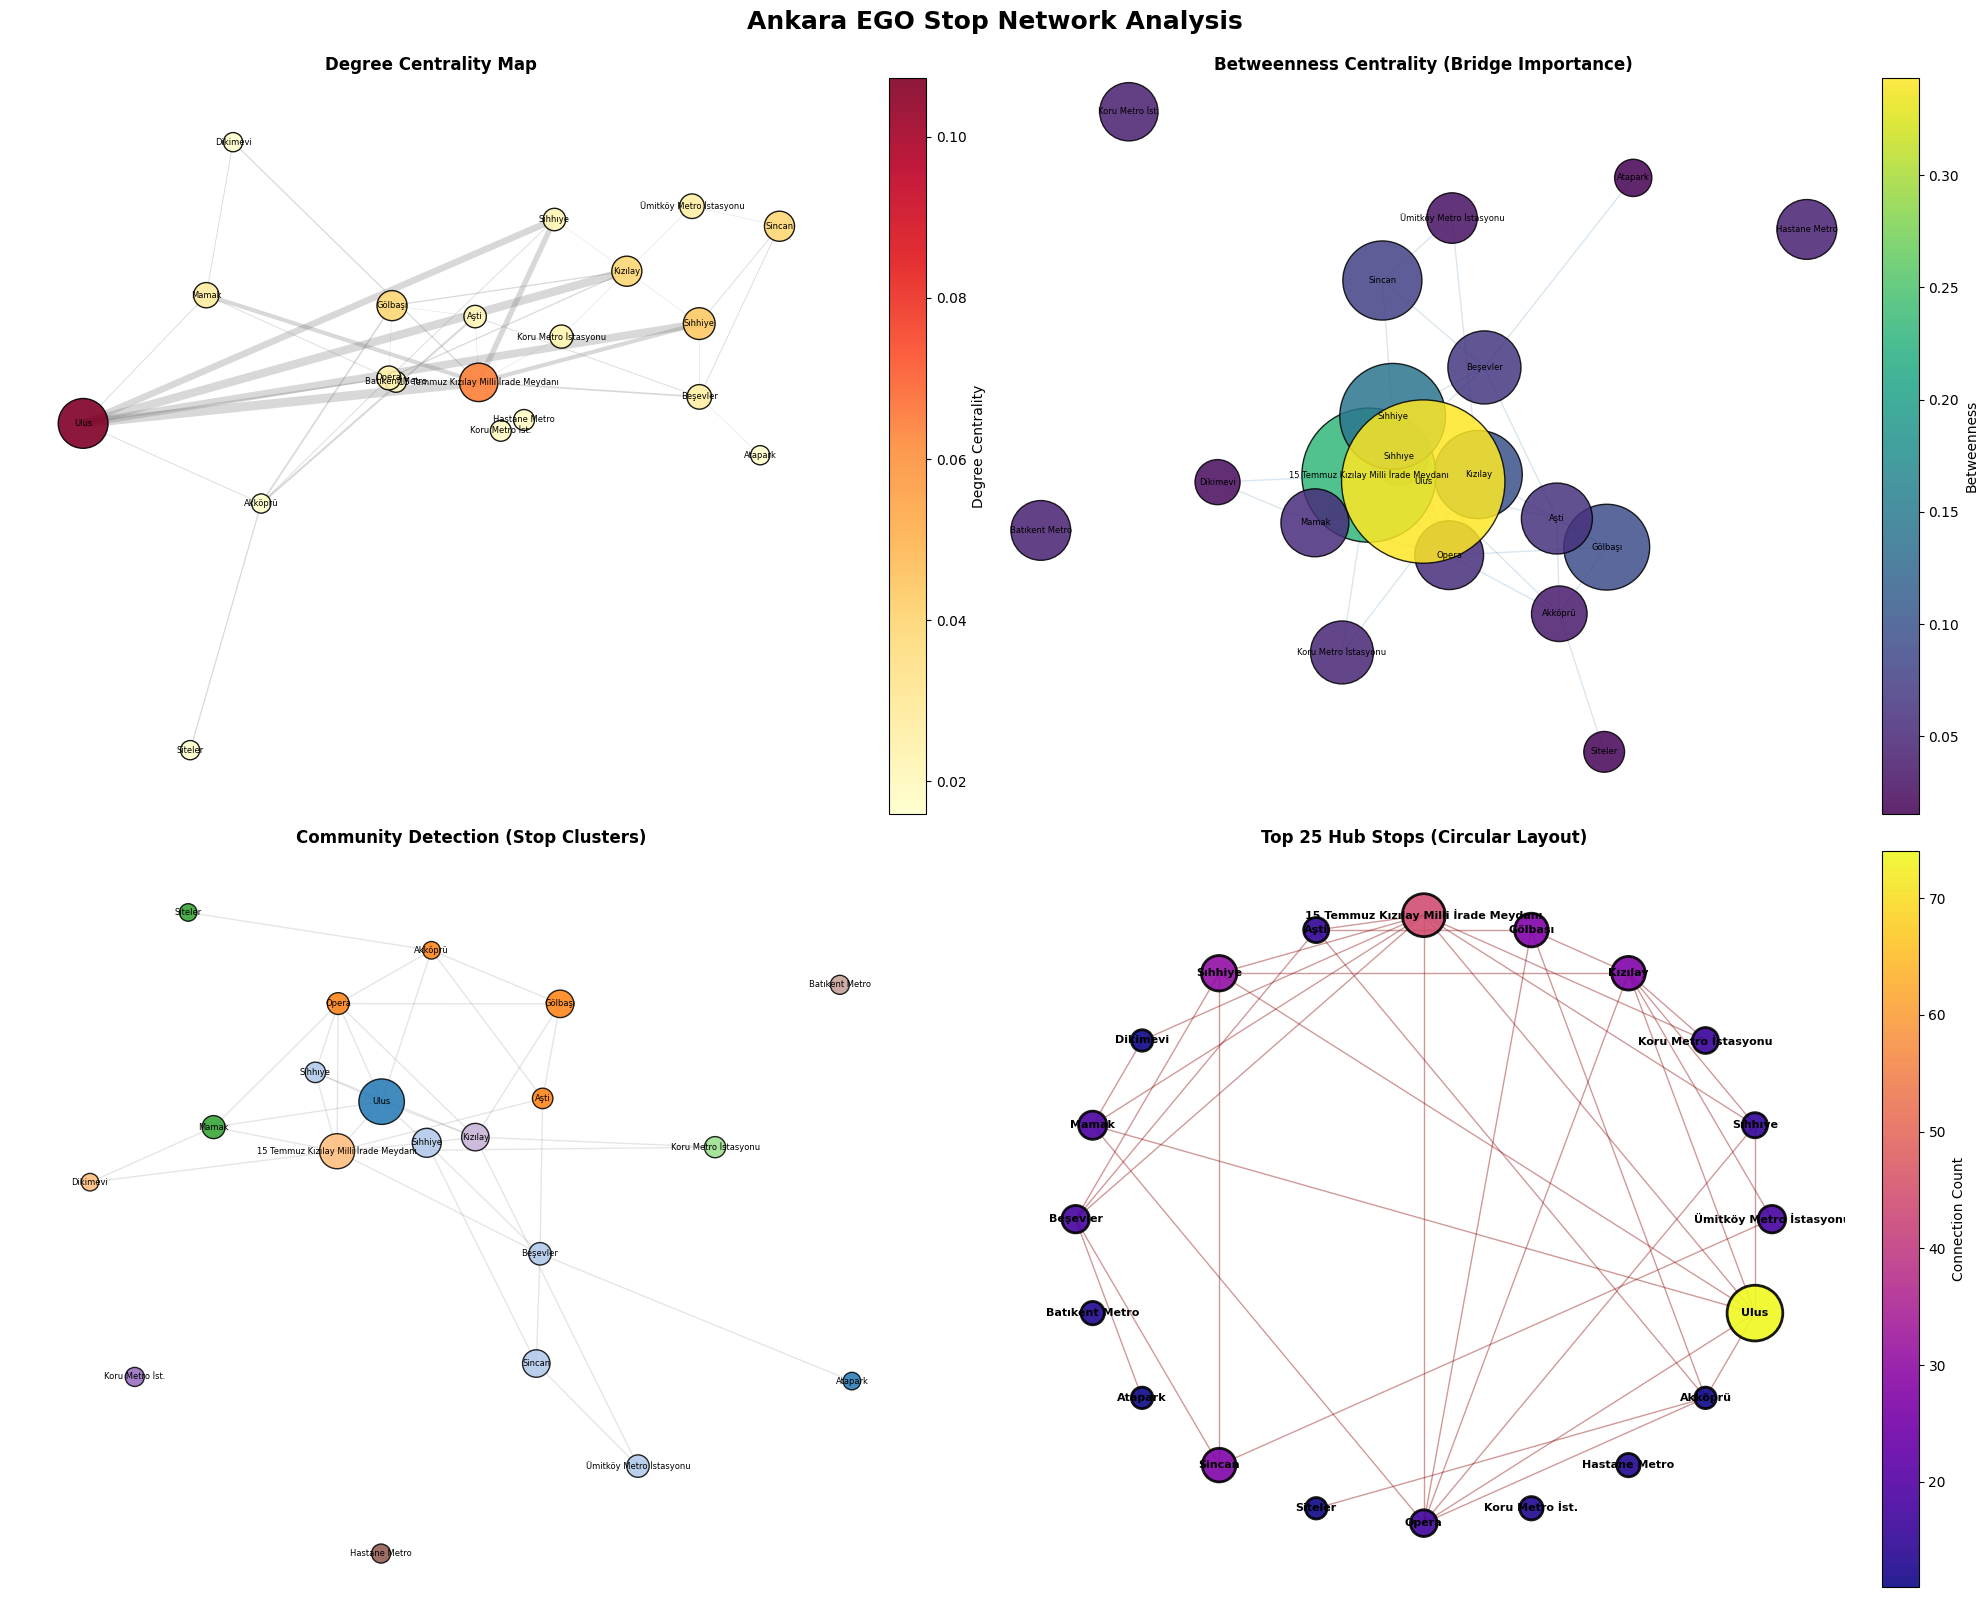


TOP 10 STRONGEST CONNECTIONS:
 1. Ulus ↔ 15 Temmuz Kızılay Milli İrade Meydanı - 22 shared routes
 2. Ulus ↔ Kızılay - 20 shared routes
 3. Ulus ↔ Sıhhiye - 19 shared routes
 4. Ulus ↔ Sıhhıye - 16 shared routes
 5. 15 Temmuz Kızılay Milli İrade Meydanı ↔ Sıhhıye - 13 shared routes
 6. 15 Temmuz Kızılay Milli İrade Meydanı ↔ Sıhhiye - 10 shared routes
 7. 15 Temmuz Kızılay Milli İrade Meydanı ↔ Mamak - 10 shared routes
 8. 15 Temmuz Kızılay Milli İrade Meydanı ↔ Ege Mahallesi - 7 shared routes
 9. Kızılay ↔ Bakanlıklar - 6 shared routes
10. Gölbaşı ↔ Yurtlar - 5 shared routes


In [24]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Create network graph from route paths
G = nx.Graph()

# Extract stops from GÜZERGAH and create edges between consecutive stops
for route_path in df['GÜZERGAH'].dropna().unique():
    stops = [s.strip() for s in str(route_path).split('-') if len(s.strip()) > 2]
    
    if len(stops) > 1:
        for i in range(len(stops) - 1):
            stop1 = stops[i]
            stop2 = stops[i+1]
            
            if G.has_edge(stop1, stop2):
                G[stop1][stop2]['weight'] += 1
            else:
                G.add_edge(stop1, stop2, weight=1)

# Calculate centrality metrics
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Community detection
from networkx.algorithms import community
communities = list(community.greedy_modularity_communities(G))

# Map nodes to communities
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

# Top central stops
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:20]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:20]

print("="*80)
print("NETWORK ANALYSIS SUMMARY")
print("="*80)
print(f"Total Stops (Nodes): {G.number_of_nodes()}")
print(f"Total Connections (Edges): {G.number_of_edges()}")
print(f"Network Density: {nx.density(G):.4f}")
print(f"Average Connections: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"Communities Detected: {len(communities)}")

# Top 5 largest communities
community_sizes = sorted([(i, len(comm)) for i, comm in enumerate(communities)],
                         key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop 5 Largest Communities:")
for i, (comm_id, size) in enumerate(community_sizes, 1):
    print(f"  {i}. Community {comm_id}: {size} stops")

print(f"\n{'='*80}")
print("MOST CENTRAL STOPS (Degree Centrality)")
print("="*80)
for i, (stop, score) in enumerate(top_degree[:10], 1):
    print(f"{i:2d}. {stop:40s} - Score: {score:.4f} - Connections: {G.degree(stop)}")

print(f"\n{'='*80}")
print("MOST IMPORTANT BRIDGE STOPS (Betweenness Centrality)")
print("="*80)
for i, (stop, score) in enumerate(top_betweenness[:10], 1):
    print(f"{i:2d}. {stop:40s} - Score: {score:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Ankara EGO Stop Network Analysis', fontsize=18, fontweight='bold', y=0.995)

# Get top 60 nodes for visualization
top_60_nodes = [stop for stop, _ in top_degree[:60]]
subgraph = G.subgraph(top_60_nodes)

# 1. Degree Centrality Map
pos1 = nx.kamada_kawai_layout(subgraph)
node_sizes_1 = [degree_centrality[node] * 12000 for node in subgraph.nodes()]
node_colors_1 = [degree_centrality[node] for node in subgraph.nodes()]
edge_weights = [subgraph[u][v]['weight'] for u, v in subgraph.edges()]

nodes1 = nx.draw_networkx_nodes(subgraph, pos1, node_size=node_sizes_1,
                                 node_color=node_colors_1, cmap='YlOrRd',
                                 alpha=0.9, edgecolors='black', linewidths=1, ax=axes[0,0])
nx.draw_networkx_edges(subgraph, pos1, width=[w*0.3 for w in edge_weights],
                       alpha=0.3, edge_color='gray', ax=axes[0,0])
nx.draw_networkx_labels(subgraph, pos1, font_size=6, ax=axes[0,0])
axes[0,0].set_title('Degree Centrality Map', fontsize=12, fontweight='bold')
axes[0,0].axis('off')
plt.colorbar(nodes1, ax=axes[0,0], fraction=0.046, pad=0.04, label='Degree Centrality')

# 2. Betweenness Centrality
pos2 = nx.spring_layout(subgraph, k=0.8, seed=42)
node_sizes_2 = [betweenness_centrality[node] * 40000 + 100 for node in subgraph.nodes()]
node_colors_2 = [betweenness_centrality[node] for node in subgraph.nodes()]

nodes2 = nx.draw_networkx_nodes(subgraph, pos2, node_size=node_sizes_2,
                                 node_color=node_colors_2, cmap='viridis',
                                 alpha=0.85, edgecolors='black', ax=axes[0,1])
nx.draw_networkx_edges(subgraph, pos2, alpha=0.2, edge_color='steelblue', ax=axes[0,1])
nx.draw_networkx_labels(subgraph, pos2, font_size=6, ax=axes[0,1])
axes[0,1].set_title('Betweenness Centrality (Bridge Importance)', fontsize=12, fontweight='bold')
axes[0,1].axis('off')
plt.colorbar(nodes2, ax=axes[0,1], fraction=0.046, pad=0.04, label='Betweenness')

# 3. Community Detection
pos3 = nx.spring_layout(subgraph, k=1.0, seed=123)
cmap_comm = cm.get_cmap('tab20')
community_colors = [cmap_comm(node_to_community.get(node, 0) % 20) for node in subgraph.nodes()]
node_sizes_3 = [degree_centrality[node] * 10000 for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos3, node_size=node_sizes_3,
                       node_color=community_colors, alpha=0.85, edgecolors='black', ax=axes[1,0])
nx.draw_networkx_edges(subgraph, pos3, alpha=0.2, edge_color='gray', ax=axes[1,0])
nx.draw_networkx_labels(subgraph, pos3, font_size=6, ax=axes[1,0])
axes[1,0].set_title('Community Detection (Stop Clusters)', fontsize=12, fontweight='bold')
axes[1,0].axis('off')

# 4. Top 25 Hub Stops (Circular Layout)
top_25_nodes = [stop for stop, _ in top_degree[:25]]
hub_graph = G.subgraph(top_25_nodes)
pos4 = nx.circular_layout(hub_graph)
node_sizes_4 = [degree_centrality[node] * 15000 for node in hub_graph.nodes()]
node_colors_4 = [G.degree(node) for node in hub_graph.nodes()]

nodes4 = nx.draw_networkx_nodes(hub_graph, pos4, node_size=node_sizes_4,
                                 node_color=node_colors_4, cmap='plasma',
                                 alpha=0.9, edgecolors='black', linewidths=2, ax=axes[1,1])
nx.draw_networkx_edges(hub_graph, pos4, alpha=0.4, edge_color='darkred', ax=axes[1,1])
nx.draw_networkx_labels(hub_graph, pos4, font_size=8, font_weight='bold', ax=axes[1,1])
axes[1,1].set_title('Top 25 Hub Stops (Circular Layout)', fontsize=12, fontweight='bold')
axes[1,1].axis('off')
plt.colorbar(nodes4, ax=axes[1,1], fraction=0.046, pad=0.04, label='Connection Count')

plt.tight_layout()
plt.show()

# Strongest connections
strongest_edges = sorted([(u, v, data['weight']) for u, v, data in G.edges(data=True)],
                         key=lambda x: x[2], reverse=True)[:10]
print(f"\nTOP 10 STRONGEST CONNECTIONS:")
for i, (stop1, stop2, weight) in enumerate(strongest_edges, 1):
    print(f"{i:2d}. {stop1} ↔ {stop2} - {weight} shared routes")

# 12. GENERAL STATISTICS AND SUMMARY REPORT

### What Does This Cell Do?
Summarizes all analyses into key performance indicators (KPIs).

### Output
- Total passengers, total trips, average occupancy
- Top performing routes
- Summary table

In [27]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from datetime import datetime
from collections import Counter

# Report time
report_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("="*80)
print("ANKARA EGO BUS SYSTEM - GENERAL SUMMARY REPORT")
print(f"Report Date: {report_time}")
print("="*80)

# =============================================================================
# SECTION 1: GENERAL STATISTICS
# =============================================================================

print("\n📊 GENERAL STATISTICS")
print("-" * 80)
total_routes = len(df)
total_stops = len(stop_counts)
total_trips = df['SEFER SAYISI'].sum()
total_passengers = df['TAŞINAN YOLCU SAYISI'].sum()
total_capacity = df['ARAÇ KAPASİTESİ'].sum()

print(f"Total Route Records: {total_routes:,}")
print(f"Total Unique Stops: {total_stops:,}")
print(f"Total Daily Trips: {total_trips:,}")
print(f"Total Daily Passengers: {total_passengers:,}")
print(f"Total Capacity: {total_capacity:,}")
print(f"System-wide Occupancy: {(total_passengers/total_capacity*100):.1f}%")

# =============================================================================
# SECTION 2: OCCUPANCY ANALYSIS
# =============================================================================

print("\n📈 OCCUPANCY ANALYSIS")
print("-" * 80)
avg_occupancy = df['DOLULUK ORANI'].mean()
median_occupancy = df['DOLULUK ORANI'].median()
max_occupancy = df['DOLULUK ORANI'].max()
min_occupancy = df['DOLULUK ORANI'].min()
high_occupancy = len(df[df['DOLULUK ORANI'] > 85])
low_occupancy = len(df[df['DOLULUK ORANI'] < 30])
mid_occ = len(df[(df['DOLULUK ORANI'] >= 30) & (df['DOLULUK ORANI'] <= 85)])

print(f"Average Occupancy: {avg_occupancy:.1f}%")
print(f"Median Occupancy: {median_occupancy:.0f}%")
print(f"Maximum Occupancy: {max_occupancy:.0f}%")
print(f"Minimum Occupancy: {min_occupancy:.0f}%")
print(f"High Occupancy Routes (>85%): {high_occupancy} ({high_occupancy/total_routes*100:.1f}%)")
print(f"Medium Occupancy Routes (30-85%): {mid_occ} ({mid_occ/total_routes*100:.1f}%)")
print(f"Low Occupancy Routes (<30%): {low_occupancy} ({low_occupancy/total_routes*100:.1f}%)")

# =============================================================================
# SECTION 3: CAPACITY AND TRIPS
# =============================================================================

print("\n🚌 CAPACITY AND TRIP ANALYSIS")
print("-" * 80)
avg_trips = df['SEFER SAYISI'].mean()
avg_capacity = df['ARAÇ KAPASİTESİ'].mean()
avg_passengers = df['TAŞINAN YOLCU SAYISI'].mean()
capacity_utilization = (total_passengers / total_capacity * 100)

print(f"Average Trips/Route: {avg_trips:.1f}")
print(f"Median Trips/Route: {df['SEFER SAYISI'].median():.0f}")
print(f"Average Capacity/Route: {avg_capacity:.0f}")
print(f"Average Passengers/Route: {avg_passengers:.0f}")
print(f"Capacity Utilization Rate: {capacity_utilization:.1f}%")
print(f"Unused Capacity: {total_capacity - total_passengers:,} ({(1-capacity_utilization/100)*100:.1f}%)")

busiest_route = df.loc[df['TAŞINAN YOLCU SAYISI'].idxmax()]
least_busy_route = df.loc[df['TAŞINAN YOLCU SAYISI'].idxmin()]

print(f"\nBusiest Route: {busiest_route['HAT NO']} - {str(busiest_route['GÜZERGAH'])[:50]}...")
print(f" → {busiest_route['TAŞINAN YOLCU SAYISI']:,} passengers ({busiest_route['DOLULUK ORANI']}% occupancy)")
print(f"\nLeast Busy Route: {least_busy_route['HAT NO']} - {str(least_busy_route['GÜZERGAH'])[:50]}...")
print(f" → {least_busy_route['TAŞINAN YOLCU SAYISI']:,} passengers ({least_busy_route['DOLULUK ORANI']}% occupancy)")

# =============================================================================
# SECTION 4: ROUTE ANALYSIS
# =============================================================================

print("\n🗺️ ROUTE ANALYSIS")
print("-" * 80)
avg_stops = df['STOP COUNT'].mean()
max_stops = df['STOP COUNT'].max()
min_stops = df['STOP COUNT'].min()
most_popular_stop = stop_counts.most_common(1)[0]

print(f"Average Stop Count: {avg_stops:.1f}")
print(f"Median Stop Count: {df['STOP COUNT'].median():.0f}")
print(f"Longest Route: {max_stops} stops")
longest_route = df.loc[df['STOP COUNT'].idxmax()]
print(f" → Route {longest_route['HAT NO']}: {str(longest_route['GÜZERGAH'])[:60]}...")
print(f"Shortest Route: {min_stops} stops")
print(f"Most Popular Stop: {most_popular_stop[0]} ({most_popular_stop[1]} routes)")

print(f"\nTop 10 Most Popular Stops:")
for i, (stop, count) in enumerate(stop_counts.most_common(10), 1):
    print(f" {i:2d}. {stop:40s} - {count:3d} routes")

# =============================================================================
# SECTION 5: REGIONAL DISTRIBUTION
# =============================================================================

print("\n🏙️ REGIONAL DISTRIBUTION")
print("-" * 80)
region_distribution = df['BÖLGE'].value_counts().head(10)
print("Top 10 Regions by Route Count:")
for i, (region, count) in enumerate(region_distribution.items(), 1):
    avg_occ = df[df['BÖLGE'] == region]['DOLULUK ORANI'].mean()
    print(f" {i:2d}. {region:30s} - {count:3d} routes (Avg Occupancy: {avg_occ:.1f}%)")

# =============================================================================
# SECTION 6: OPTIMIZATION POTENTIAL
# =============================================================================

print("\n🎯 OPTIMIZATION POTENTIAL")
print("-" * 80)
cancellation_candidates = df[(df['DOLULUK ORANI'] < 30) & (df['TAŞINAN YOLCU SAYISI'] < 100)]
capacity_increase_candidates = df[df['DOLULUK ORANI'] > 85]
route_optimization_candidates = df[(df['STOP COUNT'] >= 7) & (df['DOLULUK ORANI'] < 40)]

print(f"Cancellation Candidates: {len(cancellation_candidates)} routes ({len(cancellation_candidates)/total_routes*100:.1f}%)")
print(f"Capacity Increase Candidates: {len(capacity_increase_candidates)} routes ({len(capacity_increase_candidates)/total_routes*100:.1f}%)")
print(f"Route Optimization Candidates: {len(route_optimization_candidates)} routes ({len(route_optimization_candidates)/total_routes*100:.1f}%)")

total_optimization = len(cancellation_candidates) + len(capacity_increase_candidates) + len(route_optimization_candidates)
print(f"\nTotal Optimization Potential: {total_optimization} routes ({total_optimization/total_routes*100:.1f}%)")

# =============================================================================
# SECTION 7: EFFICIENCY METRICS
# =============================================================================

print("\n📊 EFFICIENCY METRICS")
print("-" * 80)
efficiency_score = (avg_occupancy / 100) * (capacity_utilization / 100) * 100
print(f"System Efficiency Score: {efficiency_score:.1f}/100")

if efficiency_score >= 70:
    print("Rating: ⭐⭐⭐ Excellent - System operating at high efficiency")
elif efficiency_score >= 50:
    print("Rating: ⭐⭐ Good - System performing well, room for improvement")
else:
    print("Rating: ⭐ Average - Significant improvement needed")

print(f"\nPer-Passenger Metrics:")
print(f" Trips per Passenger: {total_trips/total_passengers:.4f}")
print(f" Capacity per Passenger: {total_capacity/total_passengers:.2f}")

# =============================================================================
# SECTION 8: KEY FINDINGS
# =============================================================================

print("\n💡 KEY FINDINGS")
print("-" * 80)

findings = []
if low_occupancy > total_routes * 0.2:
    findings.append(f"⚠️ {low_occupancy} routes ({low_occupancy/total_routes*100:.1f}%) running below 30% occupancy")
if high_occupancy > total_routes * 0.1:
    findings.append(f"🔴 {high_occupancy} routes ({high_occupancy/total_routes*100:.1f}%) running above 85% occupancy - Urgent")
if capacity_utilization < 50:
    findings.append(f"📉 System-wide capacity utilization is {capacity_utilization:.1f}% - Route optimization recommended")
elif capacity_utilization > 80:
    findings.append(f"📈 System-wide capacity utilization is {capacity_utilization:.1f}% - High demand")

hub_count = len([s for s, c in stop_counts.items() if c >= 10])
findings.append(f"🚏 {hub_count} hub stops identified (10+ route intersections)")

for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")

print("\n" + "="*80)
print("REPORT END")
print("="*80)



ANKARA EGO BUS SYSTEM - GENERAL SUMMARY REPORT
Report Date: 2026-02-10 10:39:09

📊 GENERAL STATISTICS
--------------------------------------------------------------------------------
Total Route Records: 112,930
Total Unique Stops: 691
Total Daily Trips: 2,069,345
Total Daily Passengers: 170,722,567
Total Capacity: 327,776,765
System-wide Occupancy: 52.1%

📈 OCCUPANCY ANALYSIS
--------------------------------------------------------------------------------
Average Occupancy: 44.5%
Median Occupancy: 44%
Maximum Occupancy: 351%
Minimum Occupancy: 0%
High Occupancy Routes (>85%): 5283 (4.7%)
Medium Occupancy Routes (30-85%): 75822 (67.1%)
Low Occupancy Routes (<30%): 31825 (28.2%)

🚌 CAPACITY AND TRIP ANALYSIS
--------------------------------------------------------------------------------
Average Trips/Route: 18.3
Median Trips/Route: 11
Average Capacity/Route: 2902
Average Passengers/Route: 1512
Capacity Utilization Rate: 52.1%
Unused Capacity: 157,054,198 (47.9%)

Busiest Route: 550 - B